# Voice Detection — Preprocessing Pipeline

This notebook runs the VAD-based chunk extraction pipeline across VCTK, VoxCeleb1, and VOiCES datasets,
producing 3-second speech chunks and a manifest CSV for training.

## 1. Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the src package is on the path when running from notebooks/
sys.path.insert(0, str(Path("..").resolve()))

from voice_detection.data_loading import load_vctk, load_voxceleb1, load_voices
from voice_detection.preprocess import (
    load_vad_model,
    assign_speaker_splits,
    extract_chunks_from_file,
    run_preprocessing,
)

## 2. Paths

In [2]:
ROOT = Path("..").resolve()

VCTK_ROOT      = ROOT / "data/vctk/VCTK-Corpus/VCTK-Corpus"
VOXCELEB1_ROOT = ROOT / "data/voxceleb/vox1/vox1_dev_wav"
VOICES_ROOT    = ROOT / "data/voices/VOiCES_devkit"

OUT_DIR        = ROOT / "data/chunks"
MANIFEST_PATH  = ROOT / "data/manifest.csv"

# Chunking config
CHUNK_SEC   = 3.0   # duration of each chunk in seconds
STRIDE_SEC  = 1.5   # stride between chunks (1.5 s = 50% overlap)
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1
SEED        = 42

## 3. Inspect raw dataset paths and speaker counts

In [3]:
vctk_samples    = load_vctk(VCTK_ROOT)
vox1_samples    = load_voxceleb1(VOXCELEB1_ROOT)
voices_samples  = load_voices(VOICES_ROOT)

for name, samples in [("VCTK", vctk_samples), ("VoxCeleb1", vox1_samples), ("VOiCES", voices_samples)]:
    speakers = {spk for _, spk in samples}
    print(f"{name:<12} {len(samples):>7,} files   {len(speakers):>4} speakers")

VCTK          44,242 files    109 speakers
VoxCeleb1    148,642 files   1211 speakers
VOiCES           600 files    300 speakers


## 4. Preview speaker split assignment

Check how speakers are distributed across train / val / test before running the full pipeline.

In [4]:
vctk_split = assign_speaker_splits(vctk_samples, "vctk", VAL_RATIO, TEST_RATIO, SEED)

split_df = pd.DataFrame(vctk_split, columns=["wav_path", "speaker_id", "dataset", "split"])
split_summary = (
    split_df.groupby("split")
    .agg(files=("wav_path", "count"), speakers=("speaker_id", "nunique"))
    .reindex(["train", "val", "test"])
)
print("VCTK speaker split preview:")
print(split_summary)

VCTK speaker split preview:
       files  speakers
split                 
train  35381        87
val     4409        11
test    4452        11


## 5. Dry-run — extract chunks from a single file

Test VAD chunking on one file before launching the full pipeline.

In [5]:
import torchaudio

vad_model = load_vad_model()

# Pick the first VCTK training file as a test subject
test_wav, test_spk, test_dataset, test_split = vctk_split[2]

rows = extract_chunks_from_file(
    wav_path=test_wav,
    speaker_id=test_spk,
    dataset=test_dataset,
    split=test_split,
    out_dir=OUT_DIR,
    vad_model=vad_model,
    stride_sec=STRIDE_SEC,
    chunk_sec=CHUNK_SEC,
)

print(f"Source file:  {test_wav.name}")
print(f"Speaker:      {test_spk}  |  Split: {test_split}")
print(f"Chunks produced: {len(rows)}")
for row in rows:
    print(f"  {Path(row['chunk_path']).name}")

Source file:  p225_003.wav
Speaker:      vctk_p225  |  Split: train
Chunks produced: 3
  p225_003_0000.wav
  p225_003_0001.wav
  p225_003_0002.wav


## 6. Visualise a chunk spectrogram

Plot the mel spectrogram of the first extracted chunk to sanity-check the audio quality.

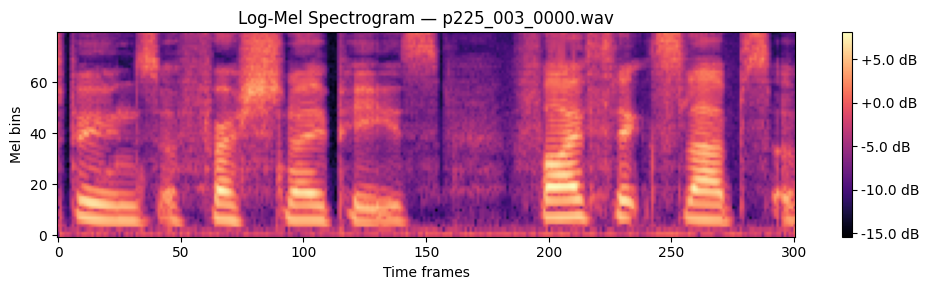

In [6]:
import torch
import soundfile as sf

if rows:
    chunk_path = Path(rows[0]["chunk_path"])
    data, sr = sf.read(str(chunk_path), dtype="float32")
    waveform = torch.from_numpy(data).unsqueeze(0)  # (1, T)

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr, n_fft=400, hop_length=160, n_mels=80
    )
    mel = mel_transform(waveform)
    log_mel = torch.log(mel + 1e-9).squeeze(0).numpy()

    fig, ax = plt.subplots(figsize=(10, 3))
    img = ax.imshow(log_mel, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"Log-Mel Spectrogram — {chunk_path.name}")
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
    plt.colorbar(img, ax=ax, format="%+.1f dB")
    plt.tight_layout()
    plt.show()
else:
    print("No chunks were produced — check the source file or VAD threshold.")

## 8. Run full pipeline

Runs the complete preprocessing across all three datasets. This will take a while — progress is shown per file.

In [8]:
rows = run_preprocessing(
    out_dir=OUT_DIR,
    manifest_path=MANIFEST_PATH,
    vctk_root=VCTK_ROOT,
    voxceleb1_root=VOXCELEB1_ROOT,
    voices_root=VOICES_ROOT,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    stride_sec=STRIDE_SEC,
    chunk_sec=CHUNK_SEC,
    seed=SEED,
)

VCTK:       44,242 files,  109 speakers
VoxCeleb1: 148,642 files, 1211 speakers
VOiCES:        600 files,  300 speakers

Total files to process: 193,484
Chunk size: 3.0 s | Stride: 1.5 s | Min speech ratio: 0.8

Loading Silero VAD model...


Extracting chunks: 100%|██████████| 193484/193484 [3:42:43<00:00, 14.48it/s]  



Done. Total chunks: 555,050

Split        Chunks   Speakers
------------------------------
train       442,315      1,295
val          59,057        162
test         53,678        162

Manifest saved to: C:\Users\Michal Lange\Documents\Voice Detection Project\data\manifest.csv


## 9. Inspect manifest and visualise chunk distribution

Total chunks: 555,050
                                          chunk_path speaker_id dataset  split
0  C:\Users\Michal Lange\Documents\Voice Detectio...  vctk_p225    vctk  train
1  C:\Users\Michal Lange\Documents\Voice Detectio...  vctk_p225    vctk  train
2  C:\Users\Michal Lange\Documents\Voice Detectio...  vctk_p225    vctk  train
3  C:\Users\Michal Lange\Documents\Voice Detectio...  vctk_p225    vctk  train
4  C:\Users\Michal Lange\Documents\Voice Detectio...  vctk_p225    vctk  train


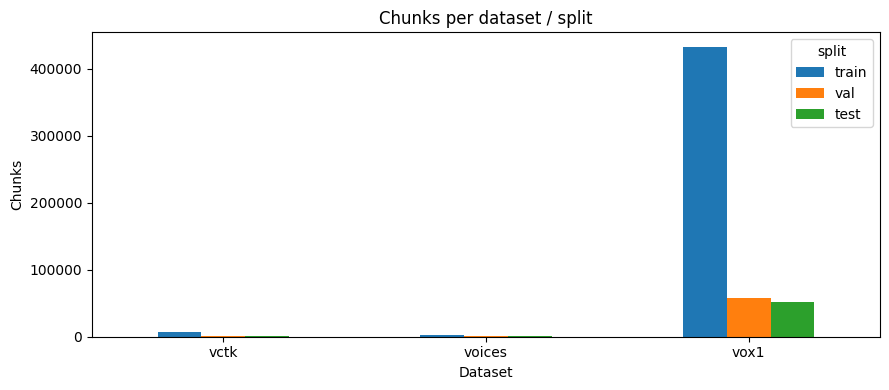

In [9]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total chunks: {len(manifest):,}")
print(manifest.head())

# Chunk counts by dataset and split
summary = (
    manifest.groupby(["dataset", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "val", "test"])
)

summary.plot(kind="bar", figsize=(9, 4), title="Chunks per dataset / split")
plt.xlabel("Dataset")
plt.ylabel("Chunks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()